## Training evaluation

This notebook purpose is to double check the model training logs before moving on to evaluation and prevent wasting resources.

In [3]:
# base_path = "/teamspace/lightning_storage/models/meta-llama-3-8b-lora-r32-adjusted-v4/metrics/"
base_path = "/teamspace/jobs/train-lora-original/artifacts/dora-case-studies/simple/outputs/meta-llama-3-8b-lora-r32-lr3e4/metrics/"
assert base_path[-1] == '/'

In [4]:
import json
import pandas as pd

In [5]:
# config overview
with open(base_path+'../run_metadata.json', 'r') as rf:
    conf = json.load(rf)

In [6]:
conf['training']

{'per_device_train_batch_size': 16,
 'gradient_accumulation_steps': 1,
 'optim': 'adamw_torch',
 'learning_rate': 0.0003,
 'lr_scheduler_type': 'linear',
 'num_train_epochs': 3,
 'warmup_steps': 100,
 'logging_steps': 50,
 'save_steps': 500,
 'save_total_limit': 3,
 'save_strategy': 'steps',
 'max_steps': -1,
 'bf16': True,
 'fp16': False,
 'max_grad_norm': 1,
 'max_length': 256,
 'packing': False,
 'gradient_checkpointing': True,
 'gradient_checkpointing_kwargs': {'use_reentrant': False},
 'dataset_text_field': 'text',
 'seed': 42,
 'report_to': 'tensorboard',
 'logging_dir': None,
 'dataloader_num_workers': 0,
 'resume_from_checkpoint': False}

In [7]:
seed = conf['training']['seed']
lr = conf['training']['learning_rate']
lora = not conf['adapter']['use_dora']
quant = conf['quantization']['enabled']

print('LoRA: {lora}, Quant: {quant}, Seed: {seed}, LR: {lr}'.format(lora=lora, quant=quant, seed=seed, lr=lr))

LoRA: True, Quant: False, Seed: 42, LR: 0.0003


   step     epoch      loss  grad_norm  learning_rate   entropy  num_tokens  \
0    50  0.004694  1.819543   0.762895       0.000147  1.806636       96387   
1   100  0.009388  1.225271   0.600766       0.000297  1.226930      195699   
2   150  0.014082  1.183095   0.518765       0.000300  1.186338      293726   
3   200  0.018776  1.156171   0.539379       0.000299  1.161066      390456   
4   250  0.023470  1.167903   0.506213       0.000299  1.167588      488326   

   mean_token_accuracy  train_runtime  train_samples_per_second  \
0             0.623225            NaN                       NaN   
1             0.733149            NaN                       NaN   
2             0.738363            NaN                       NaN   
3             0.745038            NaN                       NaN   
4             0.742799            NaN                       NaN   

   train_steps_per_second  total_flos  train_loss  
0                     NaN         NaN         NaN  
1                 

<Axes: xlabel='step'>

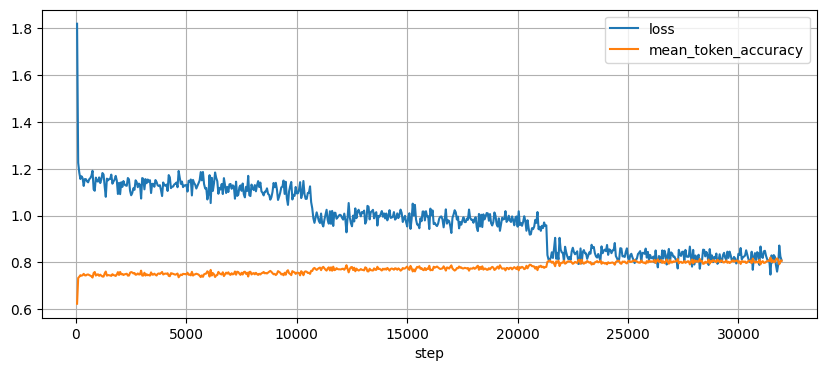

In [8]:
# path = "simple/outputs/meta-llama-3-8b-lora-r32/metrics/trainer_log.jsonl"
path = base_path+"trainer_log.jsonl"

trainer = pd.read_json(path, lines=True)

print(trainer.head())
print(trainer.columns)

# exemplo de plot
trainer.plot(x="step", y=["loss", "mean_token_accuracy"], figsize=(10, 4), grid=True)

   step     epoch  trainable_param_count  tensors_with_grad  grad_count  \
0     0  0.000000               56623104                320    56623104   
1    50  0.004694               56623104                320    56623104   
2   100  0.009388               56623104                320    56623104   
3   150  0.014082               56623104                320    56623104   
4   200  0.018776               56623104                320    56623104   

      grad_mean  grad_variance  grad_std  grad_l2_norm  grad_abs_mean  
0 -1.405308e-08   1.766063e-08  0.000133      1.000000       0.000033  
1 -2.763099e-08   1.044494e-08  0.000102      0.769042       0.000038  
2 -7.708291e-09   6.724649e-09  0.000082      0.617066       0.000033  
3 -5.764140e-09   5.018046e-09  0.000071      0.533045       0.000032  
4 -7.611027e-09   6.099094e-09  0.000078      0.587665       0.000036  
Index(['step', 'epoch', 'trainable_param_count', 'tensors_with_grad',
       'grad_count', 'grad_mean', 'grad_varianc

<Axes: xlabel='step'>

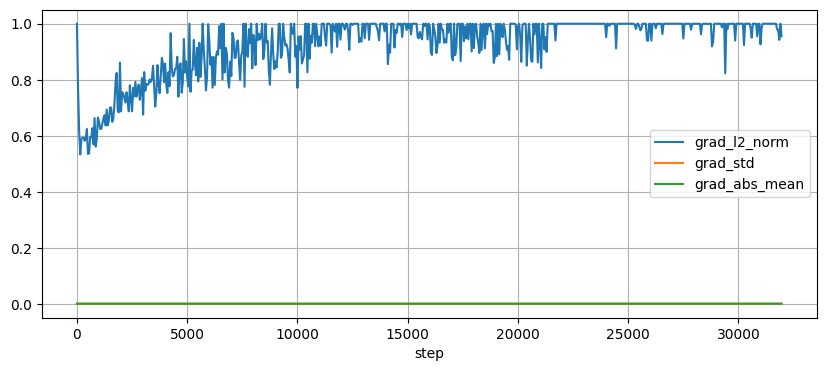

In [9]:
path = base_path+"gradient_stats.jsonl"

grad = pd.read_json(path, lines=True)

print(grad.head())
print(grad.columns)

# exemplo de plot
grad.plot(
    x="step",
    y=["grad_l2_norm", "grad_std", "grad_abs_mean"],
    figsize=(10, 4),
    grid=True
)

In [10]:
path = base_path+"magnitude_audit.json"

with open(path, "r") as f:
    magnitude_raw = json.load(f)

summary = magnitude_raw["summary"]
magnitude = pd.DataFrame(magnitude_raw["params"])

print(summary)
print(magnitude.head())
print(magnitude.columns)

# se tiver linhas em params, exemplo de plot:
if not magnitude.empty:
    magnitude.plot(figsize=(10, 4), grid=True)
else:
    print("magnitude['params'] está vazio; nada para plotar.")

{'total_magnitude_params': 0, 'trainable': 0, 'frozen': 0, 'frozen_names': []}
Empty DataFrame
Columns: []
Index: []
RangeIndex(start=0, stop=0, step=1)
magnitude['params'] está vazio; nada para plotar.


ls: cannot access 'simple/outputs/meta-llama-3-8b-qdora-r32/final_adapter': No such file or directory
